In [1]:
from torchvision import datasets, transforms
import os
import torch
import torch.nn as nn

data_path = "../../data/cifar-10/"
os.makedirs(data_path, exist_ok=True)
cifar10 = datasets.CIFAR10(data_path, train=True, download=True)
cifar10_val = datasets.CIFAR10(data_path, train=False, download=True)

label_map = {0: 0, 2:1}
class_names = ['airplane', 'bird']

tensor_cifar10 = datasets.CIFAR10(data_path, train=True, download=False,
                                  transform=transforms.ToTensor())
imgs = torch.stack([img_t for img_t, _ in tensor_cifar10], dim=3)
mean = imgs.view(3, -1).mean(dim=1)
std = imgs.view(3, -1).std(dim=1)

transform_func = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

cifar2 = [(transform_func(img), label_map[label]) for img, label in cifar10 if label in [0, 2]]
cifar2_val = [(transform_func(img), label_map[label]) for img, label in cifar10_val if label in [0, 2]]

In [2]:
# 3 represents the number of input channels (typically for a colored image with red, green, and blue channels).
# 16 represents the number of output channels.
conv = nn.Conv2d(3, 16, kernel_size=3)
conv

# So, this layer is designed to take input data with 3 channels, apply 16 different 3 * 3 convolutional filters to it,
# and produce 16 output channels as a result.

Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))

In [3]:
conv.weight.shape, conv.bias.shape

(torch.Size([16, 3, 3, 3]), torch.Size([16]))

In [4]:
img, _ = cifar2[0]
output = conv(img.unsqueeze(0))
img.unsqueeze(0).shape, output.shape

(torch.Size([1, 3, 32, 32]), torch.Size([1, 16, 30, 30]))

In [5]:
conv = nn.Conv2d(3, 1, kernel_size=3, padding=1)
output = conv(img.unsqueeze(0))
img.unsqueeze(0).shape, output.shape

(torch.Size([1, 3, 32, 32]), torch.Size([1, 1, 32, 32]))

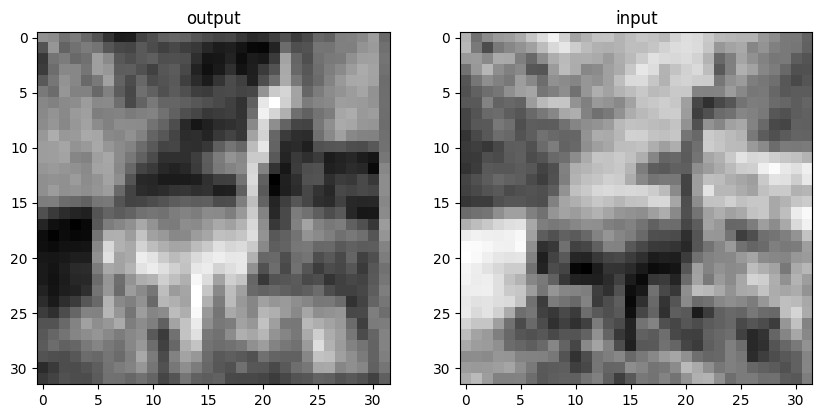

In [6]:
import matplotlib.pyplot as plt

def plot_img(img, output):
    plt.figure(figsize=(10, 4.8))
    ax1 = plt.subplot(1, 2, 1)
    plt.title('output')
    plt.imshow(output[0, 0].detach(), cmap='gray')
    plt.subplot(1, 2, 2, sharex=ax1, sharey=ax1)
    plt.imshow(img.mean(0), cmap='gray')
    plt.title('input')
    plt.show()

plot_img(img, output)

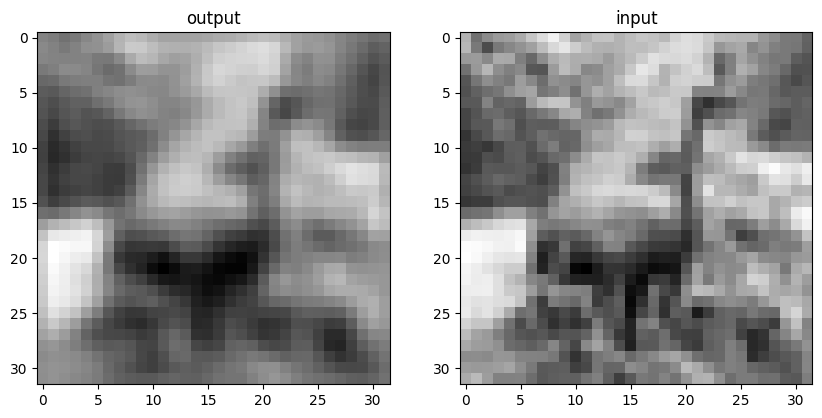

In [7]:
with torch.no_grad():
    conv.bias.zero_()
    
with torch.no_grad():
    conv.weight.fill_(1.0 / 9.0)

output = conv(img.unsqueeze(0))
plot_img(img, output)

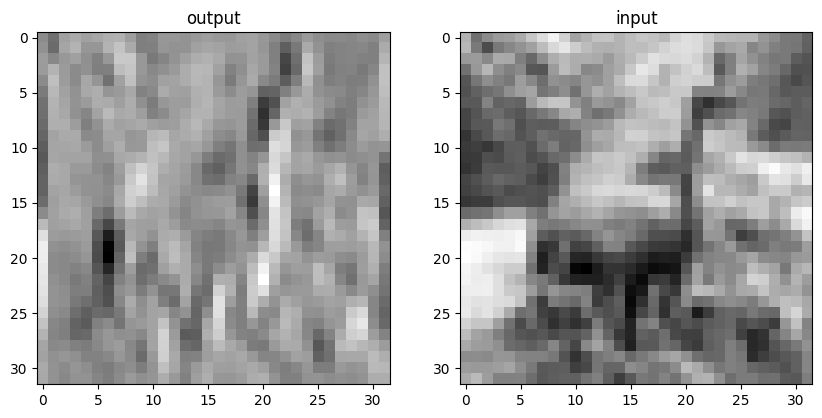

In [8]:
with torch.no_grad():
    conv.weight[:] = torch.tensor([
        [-1.0, 0.0, 1.0],
        [-1.0, 0.0, 1.0],
        [-1.0, 0.0, 1.0]
    ])
    conv.bias.zero_()

output = conv(img.unsqueeze(0))
plot_img(img, output)

In [9]:
# Subclass of nn.Module
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.act1 = nn.Tanh()
        self.pool1 = nn.MaxPool2d(2)
        
        self.conv2 = nn.Conv2d(16, 8, kernel_size=3, padding=1)
        self.act2 = nn.Tanh()
        self.pool2 = nn.MaxPool2d(2)
        
        self.fc1 = nn.Linear(8 * 8 * 8, 32)
        self.act3 = nn.Tanh()
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = self.pool1(self.act1(self.conv1(x)))
        out = self.pool2(self.act2(self.conv2(out)))
        out = out.view(-1, 8 * 8 * 8)
        out = self.act3(self.fc1(out))
        out = self.fc2(out)
        return out

In [10]:
model = Net()
num_list = [p.numel() for p in model.parameters()]
sum(num_list), num_list

(18090, [432, 16, 1152, 8, 16384, 32, 64, 2])

In [9]:
# It's a waste that we also registering submodules that have no parameters,like nn.Tanh and nn.MaxPool2d
import torch.nn.functional as F
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 8, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(8 * 8 * 8,  32)
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = F.max_pool2d(torch.tanh(self.conv1(x)), 2)
        out = F.max_pool2d(torch.tanh(self.conv2(out)), 2)
        out = out.view(-1, 8 * 8 * 8)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out

In [12]:
model = Net()
model(img.unsqueeze(0))

tensor([[0.1984, 0.1268]], grad_fn=<AddmmBackward0>)

In [7]:
import datetime

def training_loop(n_epochs, optimizer, model, loss_fn, train_loader):
    for epoch in range(1, n_epochs + 1):
        start_time = datetime.datetime.now()
        loss_train = 0.0
        for imgs, labels in train_loader:
            outputs = model(imgs)
            loss = loss_fn(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            loss_train += loss.item()
        end_time = datetime.datetime.now()
        epoch_duration = (end_time - start_time).total_seconds()
        
        if epoch == 1 or epoch % 10 == 0:
            print("{} Epoch {}, Training loss {:.6f}, Time {:.2f}s".format(
                datetime.datetime.now(), epoch,
                loss_train / len(train_loader),
                epoch_duration
            ))

In [14]:
import torch.optim as optim

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=True)
model = Net()
optimizer = optim.SGD(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

training_loop(
    n_epochs=100,
    optimizer=optimizer,
    model=model,
    loss_fn=loss_fn,
    train_loader=train_loader
)

2026-09-16 17:31:47.728705 Epoch 1, Training loss 0.582407, Time 3.26s
2026-09-16 17:32:14.523865 Epoch 10, Training loss 0.339250, Time 2.71s
2026-09-16 17:32:40.937010 Epoch 20, Training loss 0.293302, Time 2.62s
2026-09-16 17:33:17.661600 Epoch 30, Training loss 0.270807, Time 8.21s
2026-09-16 17:33:51.927322 Epoch 40, Training loss 0.252995, Time 2.99s
2026-09-16 17:34:52.913719 Epoch 50, Training loss 0.238827, Time 5.00s
2026-09-16 17:35:20.309948 Epoch 60, Training loss 0.224227, Time 2.21s
2026-09-16 17:36:36.270570 Epoch 70, Training loss 0.209319, Time 2.83s
2026-09-16 17:37:09.337941 Epoch 80, Training loss 0.192756, Time 3.18s
2026-09-16 17:37:38.784057 Epoch 90, Training loss 0.177551, Time 2.96s
2026-09-16 17:38:12.262169 Epoch 100, Training loss 0.167526, Time 2.66s


In [15]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=False)
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64, shuffle=False)


def validate(model, train_loader, val_loader):
    for name, loader in [("train", train_loader), ("val", val_loader)]:
        correct = 0
        total = 0
        
        with torch.no_grad():
            for imgs, labels in loader:
                outputs = model(imgs)
                _, predicted = torch.max(outputs, dim=1)
                total += labels.shape[0]
                correct += int((predicted == labels).sum())
        print("Accuracy {}: {:.2f}".format(name, correct / total))

validate(model, train_loader, val_loader)
                

Accuracy train: 0.90
Accuracy val: 0.86


In [16]:
# Saving and loading model
import torch
torch.save(model.state_dict(), data_path + 'birds_vs_airplanes.pt')

In [17]:
loaded_model = Net()
loaded_model.load_state_dict(torch.load(data_path + 'birds_vs_airplanes.pt'))


<All keys matched successfully>

In [18]:
class NetWidth(nn.Module):
    def __init__(self, n_chans1=32):
        super().__init__()
        self.n_chans1 = n_chans1
        self.conv1 = nn.Conv2d(3, n_chans1, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(n_chans1, n_chans1 // 2, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(8 * 8 * n_chans1 // 2, 32)
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = F.max_pool2d(torch.tanh(self.conv1(x)), 2)
        out = F.max_pool2d(torch.tanh(self.conv2(out)), 2)
        out = out.view(-1, 8 * 8 * self.n_chans1 // 2)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out, 2)
        return out

In [20]:
model = NetWidth()
sum(p.numel() for p in model.parameters())

38386

**L2 正则化推导**<br>
原始损失加上 L2 正则项后：<br>
L_total = L + λ·Σ w_i²        &nbsp;&nbsp;&nbsp;λ 是正则化超参数<br>
正则项对参数 w_i 的梯度：<br>
∂(λ·w_i²)/∂w_i = 2λ·w_i      （即文中说的负梯度为 -2λ·w_i）<br>
不带正则的 SGD 更新：<br>
w_i ← w_i − η·∂L/∂w_i <br>
带 L2 的 SGD 更新： <br>
w_i ← w_i − η·(∂L/∂w_i + 2λ·w_i) <br>
    = (1 − 2ηλ)·w_i − η·∂L/∂w_i  <br>
      └────┬────┘
   每步先把权重按比例缩小一点 <br>
对比两式：加 L2 等价于在每步更新前，先把 w_i 乘以 (1 − 2ηλ) 这个小于 1 的系数——权重朝 0 衰减，衰减量与当前值成正比（w_i 越大衰减越多，w_i 接近 0 几乎不动）。这就是 "weight decay" 名字的由来。

In [ ]:
# 总的来说，加上正则化的目的就是防止某一个权重对解的影响过大产生过拟合。
device = "cuda" if torch.cuda.is_available() else "cpu"
def training_loop_l2reg(n_epochs, optimizer, model, loss_fn, train_loader):
    for epoch in range(1, n_epochs + 1):
        loss_train = 0.0
        for imgs, labels in train_loader:
            imgs = imgs.to(device=device)
            labels = labels.to(device=device)
            outputs = model(imgs)
            loss = loss_fn(outputs, labels)
            
            l2_lambda = 0.001
            l2_norm = sum(p.pow(2.0).sum() for p in model.parameters())
            loss = loss + l2_lambda * l2_norm
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            loss_train += loss.item()
        if epoch == 1 or epoch % 10 == 0:
            print('{} Epoch {}, Training loss {}'.format(
                datetime.datetime.now(), epoch, loss_train / len(train_loader)
            ))
            

In [ ]:
# Dropout: A Simple Way to Prevent Neural Networks from Overfitting
class NetDropout(nn.Module):
    def __init__(self, n_chans1=32):
        super().__init__()
        self.n_chans1 = n_chans1
        self.conv1 = nn.Conv2d(3, n_chans1, kernel_size=3, padding=1)
        self.conv1_dropout = nn.Dropout2d(p=0.4)
        self.conv2 = nn.Conv2d(n_chans1, n_chans1 // 2, kernel_size=3, padding=1)
        self.conv2_dropout = nn.Dropout2d(p=0.4)
        self.fc1 = nn.Linear(8 * 8 * n_chans1 // 2, 32)
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = F.max_pool2d(torch.tanh(self.conv1(x)), 2)
        out = self.conv1_dropout(out)
        out = F.max_pool2d(torch.tanh(self.conv2(out)), 2)
        out = self.conv2_dropout(out)
        out = out.view(-1, 8 * 8 * self.n_chans1 // 2)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out


In [ ]:
# Batch Normalization
class NetBatchNorm(nn.Module):
    def __init__(self, n_chans1=32):
        super().__init__()
        self.n_chans1 = n_chans1
        self.conv1 = nn.Conv2d(3, n_chans1, kernel_size=3, padding=1)
        self.conv1_batchnorm = nn.BatchNorm2d(num_features=n_chans1)
        self.conv2 = nn.Conv2d(n_chans1, n_chans1 // 2, kernel_size=3, padding=1)
        self.conv2_batchnorm = nn.BatchNorm2d(num_features=n_chans1 // 2)
        self.fc1 = nn.Linear(8 * 8 * n_chans1 // 2, 32)
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = self.conv1_batchnorm(self.conv1(x))
        out = F.max_pool2d(torch.tanh(out), 2)
        out = self.conv2_batchnorm(self.conv2(out))
        out = F.max_pool2d(torch.tanh(out), 2)
        out = out.view(-1, 8 * 8 * self.n_chans1 // 2)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        
        return out

In [ ]:
# Skip connection
class NetRes(nn.Module):
    def __init__(self, n_chans1=32):
        super().__init__()
        self.n_chans1 = n_chans1
        self.conv1 = nn.Conv2d(3, n_chans1, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(n_chans1, n_chans1 // 2, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(n_chans1 // 2, n_chans1 // 2, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(4 * 4 * n_chans1 // 2, 32)
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = F.max_pool2d(torch.relu(self.conv1(x)), 2)
        out = F.max_pool2d(torch.relu(self.conv2(out)), 2)
        out1 = out
        out = F.max_pool2d(torch.relu(self.conv3(out)) + out1, 2)
        out = out.view(-1, 4 * 4 * self.n_chans1 // 2)
        out = torch.relu(self.fc1(out))
        out = self.fc2(out)
        
        return out

In [5]:
# Building very deep models with block
class ResBlock(nn.Module):
    def __init__(self, n_chans):
        super(ResBlock, self).__init__()
        self.conv = nn.Conv2d(n_chans, n_chans, kernel_size=3, padding=1, bias=False)
        self.batch_norm = nn.BatchNorm2d(num_features=n_chans)
        # 初始化 conv 的权重使用 kaiming 初始化， batch_norm 的初始化为 0 mean，0.5 variance
        torch.nn.init.kaiming_normal_(self.conv.weight, nonlinearity='relu')
        torch.nn.init.constant_(self.batch_norm.weight, 0.5)
        torch.nn.init.zeros_(self.batch_norm.bias)
        
    def forward(self, x):
        out = self.conv(x)
        out = self.batch_norm(out)
        out = torch.relu(out)
        return out + x

In [3]:
class NetResDeep(nn.Module):
    def __init__(self, n_chans1=32, n_blocks=100):
        super().__init__()
        self.n_chans1=n_chans1
        self.conv1 = nn.Conv2d(3, n_chans1, kernel_size=3, padding=1)
        self.resblokcs = nn.Sequential(*(n_blocks * [ResBlock(n_chans=n_chans1)]))
        self.fc1 = nn.Linear(8 * 8 * n_chans1, 32)
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = F.max_pool2d(torch.relu(self.conv1(x)), 2)
        out = self.resblokcs(out)
        out = F.max_pool2d(out, 2)
        out = out.view(-1, 8 * 8 * self.n_chans1)
        out = torch.relu(self.fc1(out))
        out = self.fc2(out)
        
        return out

In [ ]:
import torch.optim as optim
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=True)
model = NetResDeep()
optimizer = optim.SGD(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

training_loop(
    n_epochs=100,
    optimizer=optimizer,
    model=model,
    loss_fn=loss_fn,
    train_loader=train_loader
)

In [ ]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=False)
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64, shuffle=False)


def validate(model, train_loader, val_loader):
    for name, loader in [("train", train_loader), ("val", val_loader)]:
        correct = 0
        total = 0
        
        with torch.no_grad():
            for imgs, labels in loader:
                outputs = model(imgs)
                _, predicted = torch.max(outputs, dim=1)
                total += labels.shape[0]
                correct += int((predicted == labels).sum())
        print("Accuracy {}: {:.2f}".format(name, correct / total))

validate(model, train_loader, val_loader)
                